In [1]:
import numpy as np
import pandas as pd

# 1. The Mathematical Foundation: Gini Impurity
def calculate_gini(y):
    """
    Calculates the Gini Impurity of a set of labels.
    A Gini of 0 means the node is perfectly pure (all patients are either healthy or demented).
    """
    # Count the number of occurrences of each class in y
    counts = np.bincount(y)
    # Convert counts to probabilities
    probabilities = counts / len(y)
    # Gini formula: 1 - sum(p^2)
    gini = 1.0 - np.sum(probabilities ** 2)
    return gini

# Let's test it with dummy data to prove we understand it
test_labels_mixed = np.array([0, 1, 0, 1]) # 50% healthy, 50% demented
test_labels_pure = np.array([1, 1, 1, 1])  # 100% demented

print(f"Gini of mixed data (should be 0.5): {calculate_gini(test_labels_mixed)}")
print(f"Gini of pure data (should be 0.0): {calculate_gini(test_labels_pure)}")

Gini of mixed data (should be 0.5): 0.5
Gini of pure data (should be 0.0): 0.0


In [2]:
# 2. The Splitting Logic & Information Gain
def split_dataset(X, y, feature_index, threshold):
    """
    Splits the dataset into left and right branches based on a specific threshold.
    """
    # Create boolean masks for the split
    left_mask = X[:, feature_index] <= threshold
    right_mask = X[:, feature_index] > threshold
    
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

def calculate_information_gain(y, y_left, y_right):
    """
    Calculates how much the Gini impurity decreased after a split.
    Higher Information Gain = A better split.
    """
    parent_gini = calculate_gini(y)
    
    # Calculate the weighted average of the child nodes' Gini impurities
    p_left = len(y_left) / len(y)
    p_right = len(y_right) / len(y)
    
    child_gini = (p_left * calculate_gini(y_left)) + (p_right * calculate_gini(y_right))
    
    # Information gain is the reduction in impurity
    return parent_gini - child_gini

def get_best_split(X, y):
    """
    Iterates through all features and all unique values to find the mathematically perfect split.
    """
    best_gain = -1
    best_split = None
    n_samples, n_features = X.shape
    
    for feature_index in range(n_features):
        # Get all unique values in this column to test as possible thresholds
        thresholds = np.unique(X[:, feature_index])
        
        for threshold in thresholds:
            X_left, y_left, X_right, y_right = split_dataset(X, y, feature_index, threshold)
            
            # Skip if the split doesn't actually divide the data (e.g., all data goes to one side)
            if len(y_left) == 0 or len(y_right) == 0:
                continue
                
            gain = calculate_information_gain(y, y_left, y_right)
            
            # If this is the best split we've seen so far, save it!
            if gain > best_gain:
                best_gain = gain
                best_split = {
                    'feature_index': feature_index,
                    'threshold': threshold,
                    'X_left': X_left,
                    'y_left': y_left,
                    'X_right': X_right,
                    'y_right': y_right,
                    'gain': gain
                }
    return best_split

# --- LET'S TEST IT WITH DUMMY DATA ---
# Imagine X = [Age, Normalized Brain Volume]
X_dummy = np.array([
    [60, 0.80], # Healthy
    [75, 0.60], # Alzheimer's
    [62, 0.79], # Healthy
    [80, 0.55]  # Alzheimer's
])
y_dummy = np.array([0, 1, 0, 1]) # 0 = Healthy, 1 = Alzheimer's

best = get_best_split(X_dummy, y_dummy)
print(f"Best feature index to split on: {best['feature_index']} (0=Age, 1=Volume)")
print(f"Best threshold value: {best['threshold']}")
print(f"Information Gain: {best['gain']:.4f}")

Best feature index to split on: 0 (0=Age, 1=Volume)
Best threshold value: 62.0
Information Gain: 0.5000


In [3]:
from collections import Counter

class Node:
    """A helper class to store the rules of our tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature       # Index of feature to split on
        self.threshold = threshold   # Value to split at
        self.left = left             # Left child Node
        self.right = right           # Right child Node
        self.value = value           # If it's a leaf node, this is the predicted class (0 or 1)
        
    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    """The main algorithm."""
    def __init__(self, min_samples_split=2, max_depth=10):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        """Starts the recursive tree building process."""
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # STOPPING CRITERIA: If we hit max depth, or a node is pure, or too few samples to split
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # FIND THE BEST SPLIT (Using the logic from Cell 2)
        best_gain = -1
        best_feature, best_thresh = None, None
        
        for feature_index in range(n_features):
            X_column = X[:, feature_index]
            thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                gain = self._calculate_information_gain(y, X_column, threshold)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_index
                    best_thresh = threshold

        # If no gain was found, it's a leaf node
        if best_gain == 0:
            return Node(value=self._most_common_label(y))

        # CREATE CHILD NODES RECURSIVELY
        left_idxs, right_idxs = self._split(X[:, best_feature], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        
        return Node(best_feature, best_thresh, left, right)

    # --- MATH HELPER FUNCTIONS (From Cells 1 & 2) ---
    def _calculate_information_gain(self, y, X_column, threshold):
        parent_gini = self._gini(y)
        left_idxs, right_idxs = self._split(X_column, threshold)
        
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
            
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        child_gini = (n_l / n) * self._gini(y[left_idxs]) + (n_r / n) * self._gini(y[right_idxs])
        
        return parent_gini - child_gini

    def _gini(self, y):
        counts = np.bincount(y)
        probabilities = counts / len(y)
        return 1.0 - np.sum(probabilities ** 2)

    def _split(self, X_column, threshold):
        left_idxs = np.argwhere(X_column <= threshold).flatten()
        right_idxs = np.argwhere(X_column > threshold).flatten()
        return left_idxs, right_idxs

    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

    # --- PREDICTION LOGIC ---
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

# --- LET'S TEST THE FULL TREE ---
tree = DecisionTree(max_depth=3)
tree.fit(X_dummy, y_dummy)
predictions = tree.predict(X_dummy)
print(f"Original Labels: {y_dummy}")
print(f"Tree Predictions: {predictions}")

Original Labels: [0 1 0 1]
Tree Predictions: [0 1 0 1]


In [4]:
class RandomForest:
    """A collection of Decision Trees voting on the outcome."""
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2):
        self.n_trees = n_trees                       # Number of trees in the forest
        self.max_depth = max_depth                   # Max depth of each tree
        self.min_samples_split = min_samples_split
        self.trees = []                              # List to hold our trained trees

    def fit(self, X, y):
        """Trains multiple trees on random subsets of the data."""
        self.trees = []
        for i in range(self.n_trees):
            # Initialize a new blank tree
            tree = DecisionTree(max_depth=self.max_depth, 
                                min_samples_split=self.min_samples_split)
            
            # Get a bootstrapped sample of the data
            X_sample, y_sample = self._bootstrap_samples(X, y)
            
            # Train the tree on this specific sample
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def _bootstrap_samples(self, X, y):
        """Randomly selects rows (patients) with replacement."""
        n_samples = X.shape[0]
        # Generate random indices, allowing duplicates (replacement=True)
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def _most_common_label(self, y):
        """Helper function to find the majority vote."""
        counter = Counter(y)
        return counter.most_common(1)[0][0]

    def predict(self, X):
        """Passes the test data through all trees and takes a majority vote."""
        # Get predictions from each individual tree
        # Output shape will be: (n_trees, n_samples)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        # Swap axes so we can iterate over patients instead of trees
        # New shape: (n_samples, n_trees)
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        
        # Take the majority vote for each patient
        predictions = np.array([self._most_common_label(preds) for preds in tree_preds])
        return predictions

# --- TEST THE FOREST ---
forest = RandomForest(n_trees=3, max_depth=3)
forest.fit(X_dummy, y_dummy)
forest_predictions = forest.predict(X_dummy)

print(f"Original Labels: {y_dummy}")
print(f"Forest Predictions: {forest_predictions}")

Original Labels: [0 1 0 1]
Forest Predictions: [0 1 1 1]


In [6]:
import pandas as pd
import time
import joblib
import os

# Create the models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# 1. Load Original Data (75-patient test set)
X_train_orig = pd.read_csv('../dataset/processed/X_train.csv').values
y_train_orig = pd.read_csv('../dataset/processed/Y_train.csv').values.ravel()
X_test_orig = pd.read_csv('../dataset/processed/X_test.csv').values
y_test_orig = pd.read_csv('../dataset/processed/Y_test.csv').values.ravel()

# 2. Load New Merged Data (Generalized dataset)
X_train_merged = pd.read_csv('../dataset/processed_merged/X_train.csv').values
y_train_merged = pd.read_csv('../dataset/processed_merged/Y_train.csv').values.ravel()
X_test_merged = pd.read_csv('../dataset/processed_merged/X_test.csv').values
y_test_merged = pd.read_csv('../dataset/processed_merged/Y_test.csv').values.ravel()

print(f"Original Training Size: {X_train_orig.shape[0]} patients")
print(f"Merged Training Size: {X_train_merged.shape[0]} patients")

Original Training Size: 304 patients
Merged Training Size: 460 patients


In [8]:
def calculate_accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def calculate_recall(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    false_negatives = np.sum((y_true == 1) & (y_pred == 0))
    if (true_positives + false_negatives) == 0: return 0
    return true_positives / (true_positives + false_negatives)

def calculate_f1(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = calculate_recall(y_true, y_pred)
    if (precision + recall) == 0: return 0
    return 2 * (precision * recall) / (precision + recall)

In [9]:
# --- EXPERIMENT A: ORIGINAL DATA ---
print("--- MODEL A: ORIGINAL DATASET ---")
start_time = time.time()
# 1. Lock the random seed so the shuffle is exactly the same every time you run it!
np.random.seed(42)
rf_original = RandomForest(n_trees=50, max_depth=5)
rf_original.fit(X_train_orig, y_train_orig)
print(f"Training Time: {time.time() - start_time:.2f} seconds")

preds_orig = rf_original.predict(X_test_orig)
print(f"Accuracy: {calculate_accuracy(y_test_orig, preds_orig):.4f}")
print(f"Recall:   {calculate_recall(y_test_orig, preds_orig):.4f}")
print(f"F1-Score: {calculate_f1(y_test_orig, preds_orig):.4f}")

# Save the original model
joblib.dump(rf_original, '../models/rf_original.joblib')


# --- EXPERIMENT B: MERGED DATA ---
print("\n--- MODEL B: GENERALIZED MERGED DATASET ---")
start_time = time.time()
rf_merged = RandomForest(n_trees=50, max_depth=5)
rf_merged.fit(X_train_merged, y_train_merged)
print(f"Training Time: {time.time() - start_time:.2f} seconds")

preds_merged = rf_merged.predict(X_test_merged)
print(f"Accuracy: {calculate_accuracy(y_test_merged, preds_merged):.4f}")
print(f"Recall:   {calculate_recall(y_test_merged, preds_merged):.4f}")
print(f"F1-Score: {calculate_f1(y_test_merged, preds_merged):.4f}")

# Save the generalized model
joblib.dump(rf_merged, '../models/rf_merged.joblib')

print("\nModels successfully saved to the '../models/' directory.")

--- MODEL A: ORIGINAL DATASET ---
Training Time: 15.71 seconds
Accuracy: 0.7867
Recall:   0.6486
F1-Score: 0.7500

--- MODEL B: GENERALIZED MERGED DATASET ---
Training Time: 22.71 seconds
Accuracy: 0.8348
Recall:   0.7719
F1-Score: 0.8224

Models successfully saved to the '../models/' directory.


In [10]:
# # Find the indices where the prediction does NOT match the real label
# wrong_predictions_indices = np.where(y_test_real != test_predictions)[0]

# print("Indices of misclassified patients:", wrong_predictions_indices)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# The exact feature order from your preprocessed data
feature_names = ['M/F', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']

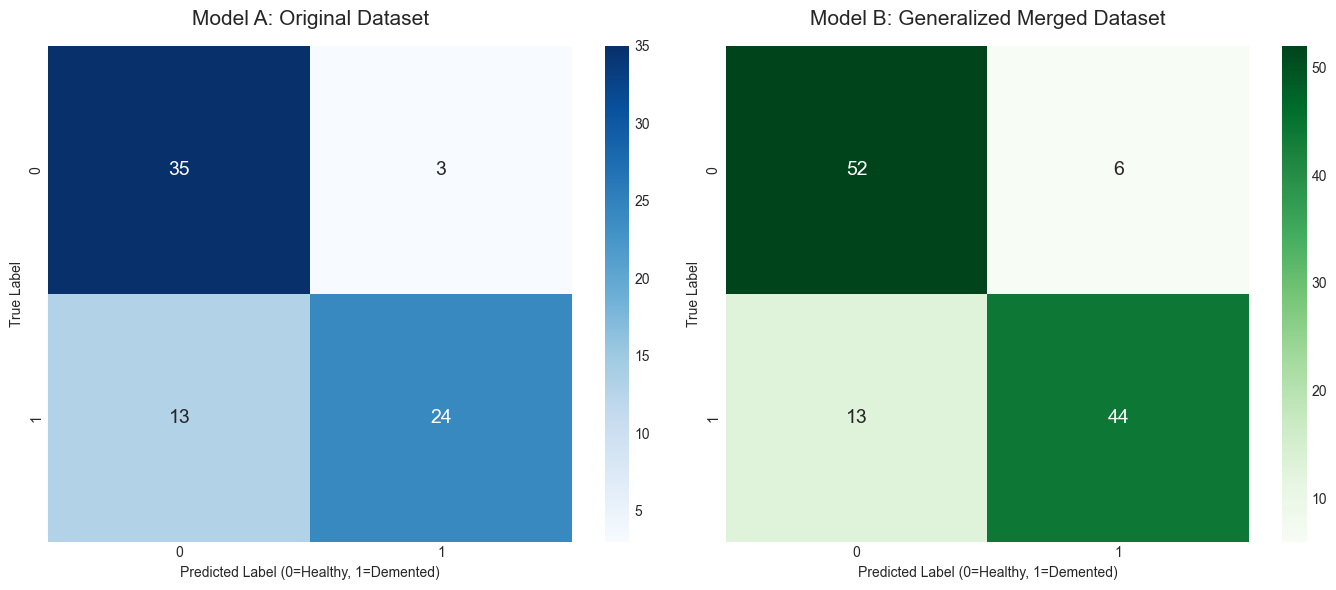

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Original Dataset Confusion Matrix
cm_orig = confusion_matrix(y_test_orig, preds_orig)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Model A: Original Dataset', fontsize=15, pad=15)
axes[0].set_xlabel('Predicted Label (0=Healthy, 1=Demented)')
axes[0].set_ylabel('True Label')

# 2. Merged Dataset Confusion Matrix
cm_merged = confusion_matrix(y_test_merged, preds_merged)
sns.heatmap(cm_merged, annot=True, fmt='d', cmap='Greens', ax=axes[1], annot_kws={"size": 14})
axes[1].set_title('Model B: Generalized Merged Dataset', fontsize=15, pad=15)
axes[1].set_xlabel('Predicted Label (0=Healthy, 1=Demented)')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../figures/rf_confusion_matrices.png', dpi=300)
plt.show()

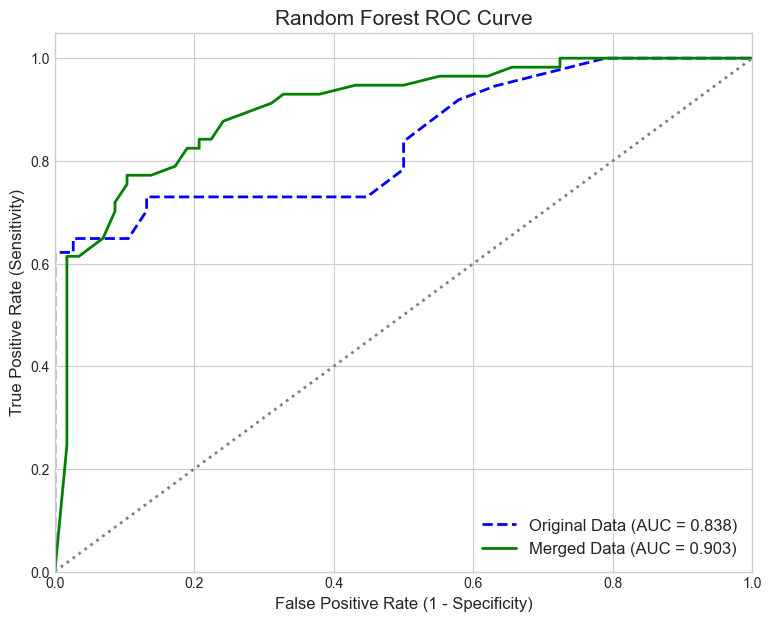

In [15]:
def get_rf_probabilities(rf_model, X):
    """Calculates the percentage of trees that voted for Alzheimer's (1)."""
    tree_preds = np.array([tree.predict(X) for tree in rf_model.trees])
    tree_preds = np.swapaxes(tree_preds, 0, 1)
    # Mean of 1s and 0s gives the probability of class 1
    return np.array([np.mean(preds == 1) for preds in tree_preds])

# Get probabilities
probs_orig = get_rf_probabilities(rf_original, X_test_orig)
probs_merged = get_rf_probabilities(rf_merged, X_test_merged)

# Calculate ROC metrics
fpr_orig, tpr_orig, _ = roc_curve(y_test_orig, probs_orig)
auc_orig = auc(fpr_orig, tpr_orig)

fpr_merged, tpr_merged, _ = roc_curve(y_test_merged, probs_merged)
auc_merged = auc(fpr_merged, tpr_merged)

# Plot
plt.figure(figsize=(9, 7))
plt.plot(fpr_orig, tpr_orig, color='blue', lw=2, linestyle='--', label=f'Original Data (AUC = {auc_orig:.3f})')
plt.plot(fpr_merged, tpr_merged, color='green', lw=2, label=f'Merged Data (AUC = {auc_merged:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Random Forest ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig('../figures/rf_roc_curve.png', dpi=300)
plt.show()

Calculating Permutation Feature Importance...


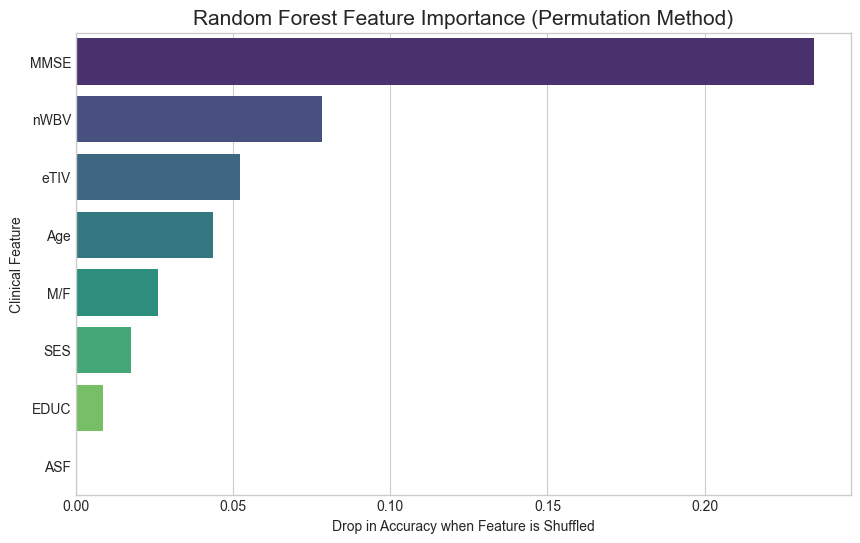

In [16]:
print("Calculating Permutation Feature Importance...")
baseline_accuracy = calculate_accuracy(y_test_merged, preds_merged)
importances = []

# Shuffle one feature at a time and see how much accuracy drops
np.random.seed(42)
for i in range(X_test_merged.shape[1]):
    X_temp = X_test_merged.copy()
    np.random.shuffle(X_temp[:, i])
    shuffled_preds = rf_merged.predict(X_temp)
    
    accuracy_drop = baseline_accuracy - calculate_accuracy(y_test_merged, shuffled_preds)
    importances.append(accuracy_drop)

# Plotting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance Drop': importances})
importance_df = importance_df.sort_values(by='Importance Drop', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance Drop', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance (Permutation Method)', fontsize=15)
plt.xlabel('Drop in Accuracy when Feature is Shuffled')
plt.ylabel('Clinical Feature')

plt.savefig('../figures/rf_feature_importance.png', dpi=300)
plt.show()

Training 2D Random Forest for Visualization...


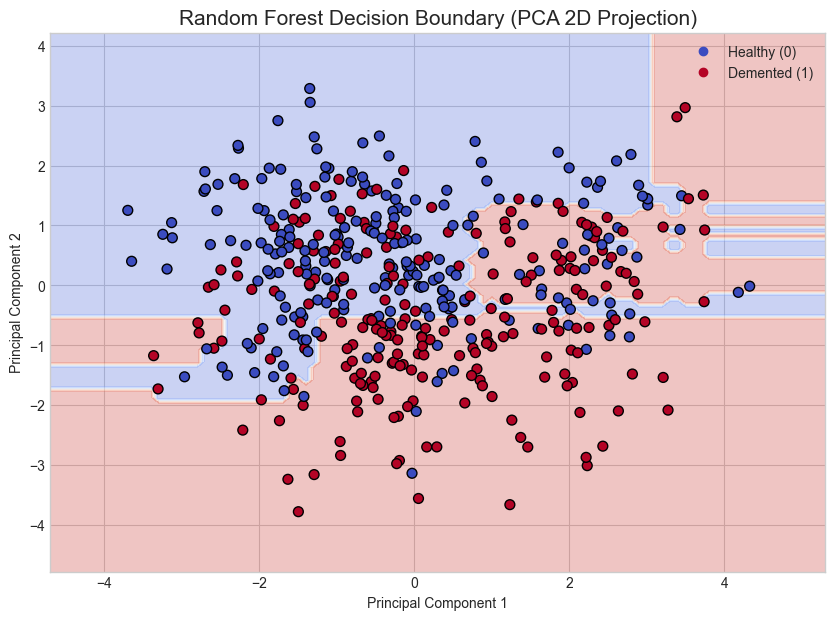

In [17]:
# 1. Compress features to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_merged)
y_train_pca = y_train_merged

# 2. Train a 2D Presentation Random Forest
print("Training 2D Random Forest for Visualization...")
rf_2d = RandomForest(n_trees=30, max_depth=5)
rf_2d.fit(X_train_pca, y_train_pca)

# 3. Create the mesh grid (background pixels)
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# 4. Predict across the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = rf_2d.predict(grid_points)
Z = Z.reshape(xx.shape)

# 5. Plot
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_pca, cmap='coolwarm', edgecolor='k', s=50)

plt.title('Random Forest Decision Boundary (PCA 2D Projection)', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Healthy (0)', 'Demented (1)'], loc="upper right")

plt.savefig('../figures/rf_decision_boundary.png', dpi=300)
plt.show()